<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification" / Mai 20-21, 2026<br> 
v1.0  - CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<div class="alert alert-block alert-danger">
<span style="color:brown;font-family:arial;font-size:normal">
     It is important to define a <span style="font-weight:bold;">Python Virtual Environment</span> (PVE) for each Python project:<br>
     a PVE makes it possible to control for each project the versions of the Python interpreter and “sensitive” modules (tensorflow...).<br> 
$\leadsto$ This notebook is run with the command `uv run jupyter lab` to ensure it uses the PVE of the projet.

<span style="font-family:arial;font-size:1cm;">
    Machine learning with tensorflow2/keras Python modules
</span>

# Training a simple Dense Neural Network to classify small images

## 0 - Preliminaries

### Configure KAGGLE environment if needed

In [1]:
import sys
from pathlib import Path

if 'kaggle' in Path.cwd().as_posix():
    KAGGLE = True
    print(f'Notebook running on KAGGLE')
else:
    KAGGLE = False
    print(f'Notebook not running on KAGGLE')


if KAGGLE:
    #
    # Add the path to the <utils> directory to the sys.path list:
    #
    paths = list(Path('/kaggle').rglob('utils'))
    if len(paths) == 0:
        print('\tNo <utils> directory found in your workspace, sorry.')
    else:
        util_path = paths[0].parent

        util_path = paths[0].parent.as_posix()
        sys.path.append(util_path)
        print(f'\t<{util_path}> added to sys.path.')

    #
    # Create a link <img> to the image directory of the dataset éDL img"
    #
    img_dataset_path = Path('/kaggle/input/datasets/jlcharles/dl-img')
    link_to_img_dir  = Path.cwd() / 'img'
    if not link_to_img_dir.is_symlink(): 
        link_to_img_dir.symlink_to(img_dataset_path)
    print(f'\tlink <{link_to_img_dir}> to <{img_dataset_path}> OK')

Notebook not running on KAGGLE


#### On KAGGLE platform we must install the GPUtil module:

In [2]:
! test $(pwd) = '/kaggle/working' && pip install GPUtil

### Import the Python modules

In [3]:
# suppress tensorflow verbose warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [4]:
# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys
import random
import cv2

# Custom modules:
from utils.tools import scan_dir, plot_images, plot_loss_accuracy, elapsed_time_since, show_conf_matrix, plot_proportion_bar

I0000 00:00:1774884412.652018  259695 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774884412.652508  259695 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774884413.527591  259695 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774884413.527847  259695 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")
print(f"OpenCV    : {cv2.__version__}")

Python    : 3.13.12
tensorflow: 2.21.0 with keras 3.13.2
numpy     : 2.4.4
OpenCV    : 4.13.0


In [6]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

#### Check wether GPU is available or not:

In [7]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("No GPU found. Using CPU.")

No GPU found. Using CPU.


### Create the `models` directory

In [9]:
if Path.cwd().name != 'Notebooks':
    print("You should save & close this notebook and type 'uv run jupyter lab'")
    print("from the <Notebooks> directory")
else:
    print(f'{"WORKING DIRECTORY":20s}: {Path.cwd()}')
    model_path = Path("./models")
    model_path.mkdir(exist_ok=True)
    print(f'{"MODELS DIRECTORY":20s}: {model_path.absolute().as_posix()}')

WORKING DIRECTORY   : /home/jlc/work/IA-MachineLearning/18-DIADEM/Notebooks
MODELS DIRECTORY    : /home/jlc/work/IA-MachineLearning/18-DIADEM/Notebooks/models


## 1 - Prepare the MNIST dataset (images and labels)

#### Loading of the data

In [10]:
(train_img, train_lab), (valid_img, valid_lab) = keras.datasets.mnist.load_data()

### Create the 3 datasets: train, validation & test

In [11]:
# note on train_test_split : Stratified train/test split is not implemented for shuffle=False 
# We give the seed value with the 'random_state' parameter to ensure a reproducible splitting.

valid_img, test_img, valid_lab, test_lab = train_test_split(valid_img, valid_lab,
                                                            stratify=valid_lab,
                                                            test_size=0.5,
                                                            shuffle=True,
                                                            random_state=SEED)

### Define important parameters

In [36]:
NB_TRAIN_IMG = train_img.shape[0] # number of training images
NB_VALID_IMG = valid_img.shape[0] # number of validation images 
NB_TEST_IMG  = test_img.shape[0]  # number of test images
NB_PIXEL     = train_img[0].size  # number of elements (pixels) of the firts training image
NB_CLASS     = len(set(train_lab)) # number of classes:

## 3 - Process input data

### Transform input matrices into normalized vectors

In [37]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255
x_test  = test_img.reshape(NB_TEST_IMG, NB_PIXEL)/255

### *one-hot* encoding of labels:

In [15]:
from tensorflow.keras.utils import to_categorical
# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

## 4 - Build the Dense Neural Network (DNN)

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/Simple-DNN.png" alt="Simple-DNN.png" style="width:900px;"><br>
     [image credit: JLC]

In [16]:
NB_INPUT  = NB_PIXEL
NB_NEURON = NB_PIXEL

For the sake of convenience we défine a function to build the NN: 

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Dropout, BatchNormalization


def build_DNN(seed=None):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential()
    model.add(Input(shape=(NB_INPUT,), name='input'))             # INPUT layer
    model.add(Dropout(0.3, seed=seed))                            # drop out 
    model.add(Dense(NB_NEURON, activation='relu', name='c1'))     # First hidden layer
    model.add(Dense(NB_CLASS, activation='softmax', name='c2'))   # OUTPUT layer
    model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
    return model

Lets's look at the number of _parameters_ (the _weights_) of the model:

In [29]:
model = build_DNN(seed=1234)
model.save('models/DNN_seed1234_drop-0.3_init.keras')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_2 (Dropout)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c1 (Dense)                      │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c2 (Dense)                      │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

## 7 - Train the network

### Automatically stop training before over-fit
Keras offers tools to automatically stop learning by monitoring for example the growth of `val_accuracy` or the decrease of `val_loss` from one epoch to another (see the _EarlyStopping_ callback).

We can thus define a list of callback functions that we pass as an argument to the `fit` method with the agument named _callbacks_:

Epoch 1/25


/home/jlc/work/IA-MachineLearning/18-DIADEM/Notebooks/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9238 - loss: 0.2485 - val_accuracy: 0.9646 - val_loss: 0.1204
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9633 - loss: 0.1171 - val_accuracy: 0.9754 - val_loss: 0.0806
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9706 - loss: 0.0907 - val_accuracy: 0.9770 - val_loss: 0.0774
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9761 - loss: 0.0727 - val_accuracy: 0.9794 - val_loss: 0.0701
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9799 - loss: 0.0616 - val_accuracy: 0.9802 - val_loss: 0.0672
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9817 - loss: 0.0555 - val_accuracy: 0.9822 - val_loss: 0.0611
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9833 - loss: 0.0499 - val_accuracy: 0.9802 - val_loss: 0.0679
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9841 - loss: 0.0455 - val_accurac

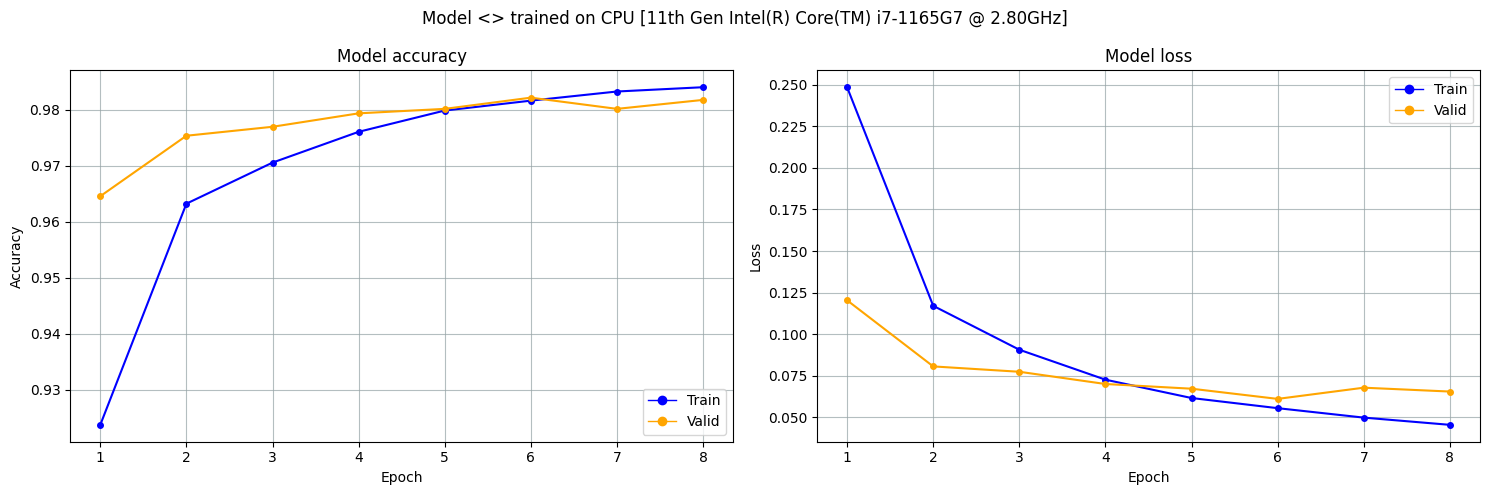

In [31]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# define the list of 'callback' fucntions:
callbacks_list = [
    EarlyStopping(monitor='val_loss',  # The parameter to monitor
                  patience=2,           # accept that 'val_accuracy' decrease 2 times
                  restore_best_weights=True,
                  verbose=1)
]

# load the network structure & initial weights:
model = tf.keras.models.load_model('models/DNN_seed1234_drop-0.3_init.keras')

# Deterministic tensorflow training: 
tf.keras.utils.set_random_seed(1234)  # sets seeds for base-python, numpy and tf
tf.config.experimental.enable_op_determinism() 

hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=25,     # the total number of successive trainings
                 batch_size=32, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)
plot_loss_accuracy(hist);

### Save the trained model

In [32]:
model.save('models/DNN_seed1234_drop-0.3_trained.keras')

## 8 - Evaluate the trained network <a name="6"></a>

#### Load the structure and weights of a trained model:

In [33]:
model = tf.keras.models.load_model('models/DNN_seed1234_drop-0.3_trained.keras')

#### Evaluate the predictions of the model:

In [34]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

# Predicting labels for test images
predict_labels = np.argmax(model.predict(x_test), axis=-1)

# Display classification report
print("Classification Report:\n", classification_report(test_lab, predict_labels))

157/157 - 0s - 2ms/step - accuracy: 0.9834 - loss: 0.0574
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       490
           1       0.99      0.99      0.99       567
           2       0.99      0.98      0.98       516
           3       0.97      0.98      0.98       505
           4       0.99      0.97      0.98       491
           5       0.99      0.99      0.99       446
           6       1.00      0.97      0.99       479
           7       0.98      0.98      0.98       514
           8       0.98      0.98      0.98       487
           9       0.97      0.99      0.98       505

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



### Show the confusion matrix

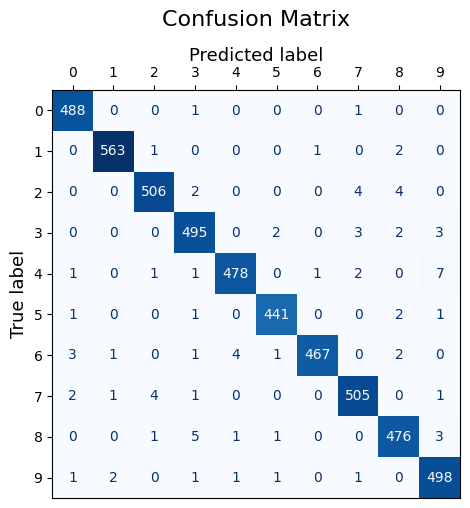

In [35]:
show_conf_matrix(test_lab, predict_labels, range(NB_CLASS), figsize=(7,6));